Name: **Vamsi Krishna Pentela**

Assignment Name: **Deliverable 4: Final Insights, Recommendations, and Presentation**

Subject Name: **Advanced Big Data and Data Mining**

**Importing Libraries and Setting the Random Seed**

The necessary libraries were imported with pandas, numpy, matplotlib.pyplot, seaborn, and some of the modules of the scikit-learn library. The functions train_test_split, GridSearchCV, StandardScaler, OneHotEncoder, LinearRegression, RandomForestRegressor, KMeans and PCA were prepared for analysis.

In [61]:
# Importing data handling libraries
import pandas as pd
import numpy as np

# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Importing model selection functions
from sklearn.model_selection import train_test_split, GridSearchCV

# Importing preprocessing functions
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Importing regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Importing classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Importing clustering methods
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Importing evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

# Importing association rule methods
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import (
    apriori,
    association_rules
)

# Importing warning handling
import warnings

# Ignoring warning messages
warnings.filterwarnings("ignore")

# Setting a fixed random value
np.random.seed(42)

**Loading and Inspecting the Telco Customer Churn Dataset**

Telco Customer Churn has been loaded into the data chunk from the specified file location. Data set size and first five data records were shown for an initial review.

In [62]:
# Setting the dataset file path
file_path = "E:/Telco-Customer-Churn.csv"

# Loading the dataset
telco_data = pd.read_csv(file_path)

# Showing the dataset shape
print("Dataset Shape:")
print(telco_data.shape)

# Showing the first five records
display(telco_data.head())

Dataset Shape:
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Checking Dataset Information**

The details of the datasets were explored to view the available columns, data types, non null values and memory usage. This information was used to ensure that the cleaned data was of good quality and had the correct structure.

In [63]:
# Checking dataset information
telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Checking Missing Values**

Each column of the data set was filled in with missing values. Result was presented to see if there were any missing values.

In [64]:
# Calculating missing values
missing_values = telco_data.isnull().sum()

# Displaying missing values
print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**Cleaning Total Charges Data**

The values of the total charges were converted to numeric values and missing charges were detected. Total charges missing were filled in with the monthly charges and the remaining missing charges were verified.

In [65]:
# Converting TotalCharges to numeric values
telco_data["TotalCharges"] = pd.to_numeric(telco_data["TotalCharges"], errors="coerce")

# Checking missing TotalCharges values before cleaning
print("Missing TotalCharges Before:")
print(telco_data["TotalCharges"].isnull().sum())

# Filling missing TotalCharges values
telco_data["TotalCharges"] = telco_data["TotalCharges"].fillna(telco_data["MonthlyCharges"])

# Checking remaining missing values
print("Missing Values After Cleaning:")
print(telco_data.isnull().sum().sum())

Missing TotalCharges Before:
11
Missing Values After Cleaning:
0


**Checking and Removing Duplicate Records**

When the data set contained duplicate records, they were identified and eliminated. It was then verified by examining the end size of the data set to ensure that the data structure was correct after cleaning.

In [66]:
# Counting duplicate records
duplicates = telco_data.duplicated().sum()

# Displaying duplicate record count
print("Duplicate Records:", duplicates)

# Removing duplicate records when found
if duplicates > 0:
    telco_data = telco_data.drop_duplicates()

# Displaying the final dataset shape
print("Final Dataset Shape:")
print(telco_data.shape)

Duplicate Records: 0
Final Dataset Shape:
(7043, 21)


**Exploring Customer Churn Distribution**

The churn categories of the customers were visualised to compare the number of customers in each churn category. The chart showed the distribution of customers based on churn status.

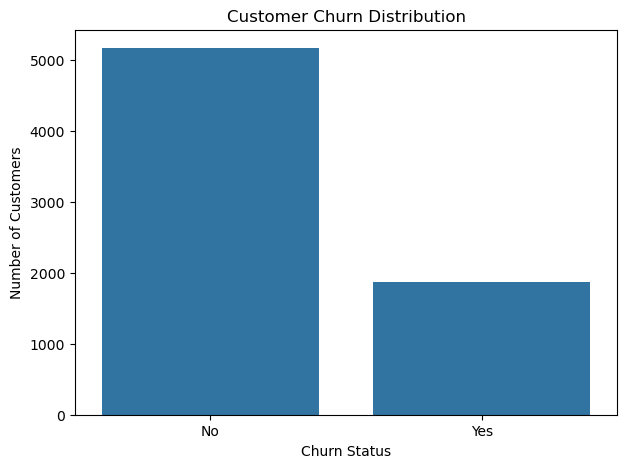

In [67]:
# Creating the churn distribution figure
plt.figure(figsize=(7, 5))

# Plotting customer churn counts
sns.countplot(data=telco_data, x="Churn")

# Adding the chart title
plt.title("Customer Churn Distribution")

# Adding the x axis label
plt.xlabel("Churn Status")

# Adding the y axis label
plt.ylabel("Number of Customers")

# Displaying the chart
plt.show()

A higher number of customers are retained than churned, as revealed in the customer churn distribution. Non-churned customers made up the bulk of customers, suggesting a higher level of customer retention. A smaller proportion of churned customers are accounted for, showcasing an imbalanced distribution class. The distribution indicates that a good churn prediction algorithm is required to identify churners.

**Calculating Churn Percentage**

The data set was used to determine the percentage of each churn group. Results rounded to 2 decimals and presented for comparison.

In [68]:
# Calculating churn percentages
churn_percentage = telco_data["Churn"].value_counts(normalize=True) * 100

# Displaying rounded percentages
display(churn_percentage.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

**Analyzing Monthly Charges by Churn**

A box plot was used to compare the monthly charge values of the churn categories. The graph revealed differences in charge levels, spread, and possible outliers between the groups.

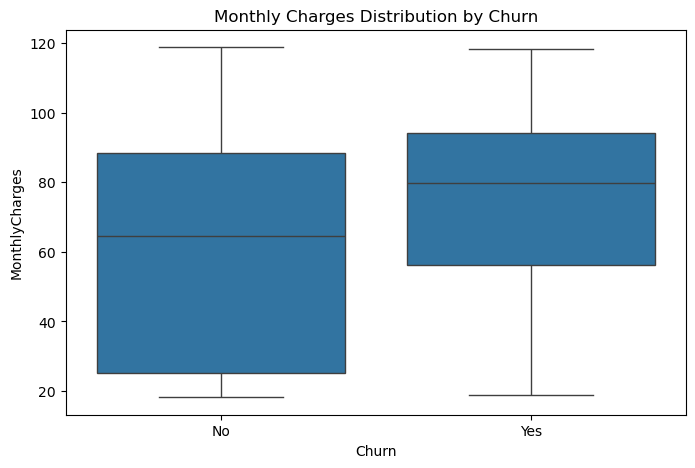

In [69]:
# Creating the monthly charges figure
plt.figure(figsize=(8, 5))

# Comparing monthly charges across churn groups
sns.boxplot(data=telco_data, x="Churn", y="MonthlyCharges")

# Adding the chart title
plt.title("Monthly Charges Distribution by Churn")

# Displaying the chart
plt.show()

The median charges for monthly charges are higher on churned customers than on retained customers. Churned customers have higher billings, there might be a relationship between charges and churn. Retained customers have a broader distribution of monthly charges, and have a lower mode. Increased monthly fees could be a big factor affecting customer attrition rates.

**Analyzing Churn by Contract Type**

Percentages have been calculated for each contract type to compare churn across contract types. The results were displayed and presented in a bar chart for easier comparison.

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


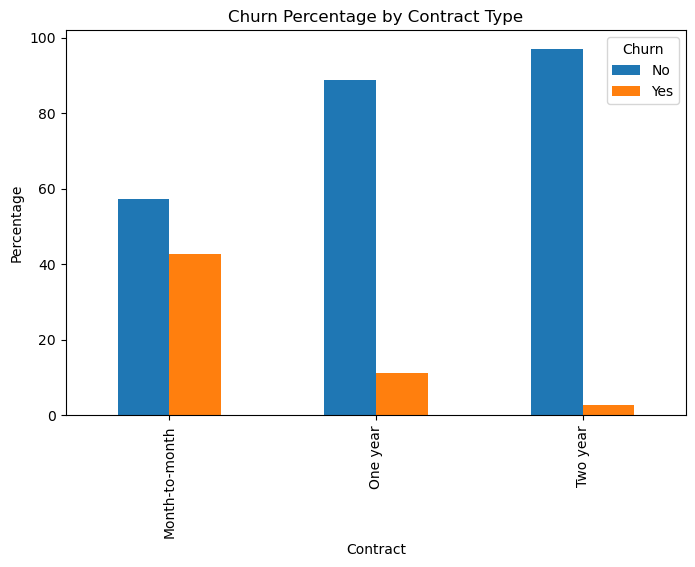

In [70]:
# Calculating churn percentages by contract type
contract_churn = pd.crosstab(telco_data["Contract"], telco_data["Churn"], normalize="index") * 100

# Displaying rounded churn percentages
display(contract_churn.round(2))

# Creating the contract churn chart
contract_churn.plot(kind="bar", figsize=(8, 5))

# Adding the chart title
plt.title("Churn Percentage by Contract Type")

# Adding the y axis label
plt.ylabel("Percentage")

# Displaying the chart
plt.show()

Contract type analysis reveals that the churn percentage of the month-to-month customers is the highest. In comparison, one-year and two-year contracts show much lower churn rates, signifying better customer retention. Correlation between long-term contracts and customer stability and low probability of churning. One of the key parameters affecting customer attrition is the duration of the contract.

**Analyzing Internet Service and Churn**

The percentage changes were compared between the different internet service categories. The results were displayed and presented in a bar chart to show differences in churn levels.

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


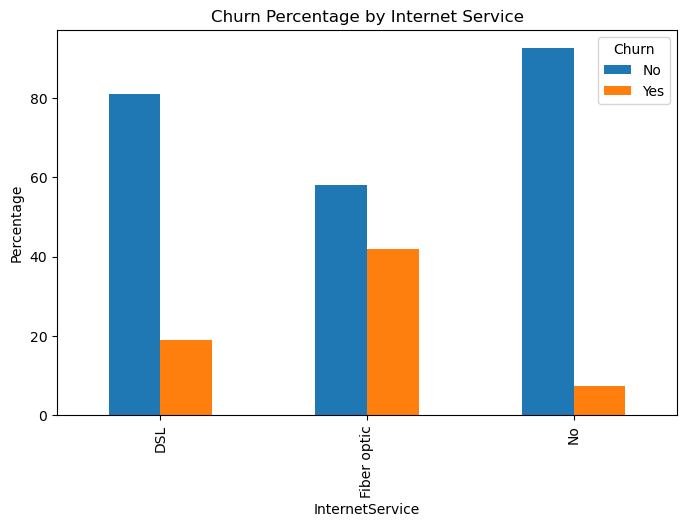

In [71]:
# Calculating churn percentages by internet service
internet_churn = pd.crosstab(telco_data["InternetService"], telco_data["Churn"], normalize="index") * 100

# Displaying rounded churn percentages
display(internet_churn.round(2))

# Creating the internet service churn chart
internet_churn.plot(kind="bar", figsize=(8, 5))

# Adding the chart title
plt.title("Churn Percentage by Internet Service")

# Adding the y axis label
plt.ylabel("Percentage")

# Displaying the chart
plt.show()

The analysis of Internet service shows that fiber optic service has a higher churn percentage than other service categories. The highest churn rate is observed among fiber optic customers, which could suggest a correlation with customer grievances or issues with the service. Moderate churn is seen with customers on DSL and lowest churn is observed with customers who have no internet service. Internet service type is one of the major factors that influences customer churn.

**Analyzing Numerical Feature Correlation**

The quantitative variables were chosen to investigate the quantitative relationships. A correlation heatmap was constructed to illustrate the relationships between the numerical variables and their strengths and directions.

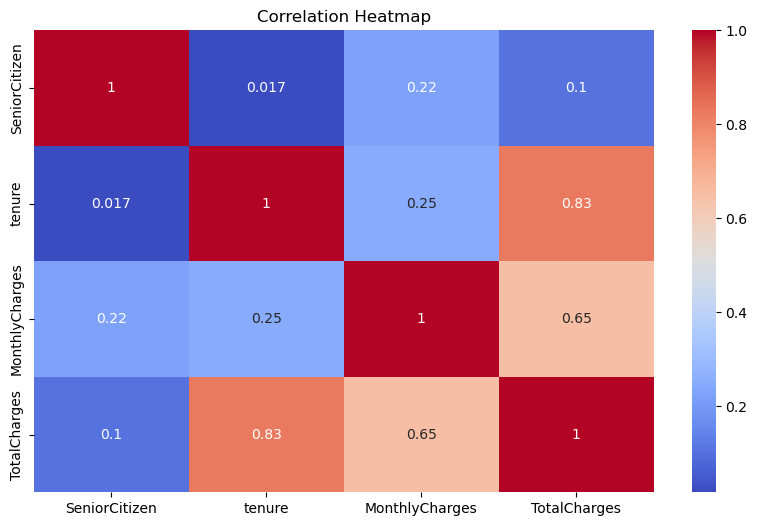

In [72]:
# Selecting numerical columns
numeric_columns = telco_data.select_dtypes(include=["int64", "float64"]).columns

# Creating the correlation figure
plt.figure(figsize=(10, 6))

# Creating the correlation heatmap
sns.heatmap(telco_data[numeric_columns].corr(), annot=True, cmap="coolwarm")

# Adding the chart title
plt.title("Correlation Heatmap")

# Displaying the chart
plt.show()

Correlation analysis shows a strong positive relationship between tenure and total charges with a correlation value of 0.83. There is a moderate positive correlation (0.65) between monthly charges and total charges. Correlation value is 0.25, which is a weak positive relationship for Tenure and Monthly charges. Other numeric characteristics do not exhibit significant overlap with senior citizen status, suggesting that they are not strongly affected by senior citizen status.

**Preparing Data for Modeling**

A separate dataset was created for modeling, and the customer identification column was removed. The churn categories were coded as numbers and the records were prepared for review.

In [73]:
# Creating a separate dataset for modeling
model_data = telco_data.copy()

# Removing the customer identification column
model_data = model_data.drop(columns=["customerID"])

# Converting churn categories into numeric values
model_data["Churn"] = model_data["Churn"].map({"No": 0, "Yes": 1})

# Displaying the prepared dataset
display(model_data.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


**Separating Features and Target**

The data set was split to features and target variable for further modeling. Both parts were printed with their dimensions to ensure that the resulting data structure was correct.

In [74]:
# Separating input features
X = model_data.drop(columns=["Churn"])

# Separating the target variable
y = model_data["Churn"]

# Showing feature dimensions
print(X.shape)

# Showing target dimensions
print(y.shape)

(7043, 19)
(7043,)


**Splitting Data into Training and Testing Sets**

The pre-processed data was segmented into training and testing sets in an 80:20 ratio. Stratified sampling was used to ensure the same churn distribution between the two sets.

In [75]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Showing training feature dimensions
print(X_train.shape)

# Showing testing feature dimensions
print(X_test.shape)

(5634, 19)
(1409, 19)


**Building the Data Preprocessing Pipeline**

Data types of numerical and categorical were differentiated for data pre-processing. All the numerical attributes were scaled and all the categorical variables were transformed to appropriate numbers for modeling.

In [76]:
# Selecting numerical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

# Selecting categorical features
categorical_features = X.select_dtypes(include=["object"]).columns

# Creating the preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[("numeric", StandardScaler(), numeric_features), ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)])

**Preparing Data for Monthly Charges Prediction**

A regression data set was created to predict the monthly charges for the available customer features. Target variable was split and data was split into training and testing sets with an 80-20 ratio.

In [77]:
# Creating the regression dataset
regression_data = telco_data.drop(columns=["customerID"])

# Converting churn categories into numeric values
regression_data["Churn"] = regression_data["Churn"].map({"No": 0, "Yes": 1})

# Separating the predictor variables
X_reg = regression_data.drop(columns=["MonthlyCharges"])

# Separating the target variable
y_reg = regression_data["MonthlyCharges"]

# Splitting the regression data into training and testing sets
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

**Preprocessing Regression Features**

The predictor variables were split into categorical and numerical variables for regression preprocessing. The numerical variables were normalized and the categorical variables were converted into numerical variables to be trained.

In [78]:
# Selecting numerical regression features
reg_num = X_reg.select_dtypes(include=["int64", "float64"]).columns

# Selecting categorical regression features
reg_cat = X_reg.select_dtypes(include=["object"]).columns

# Creating the regression preprocessing pipeline
reg_processor = ColumnTransformer([("num", StandardScaler(), reg_num), ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), reg_cat)])

**Training the Model Linear Regression**

The linear regression model was trained with the prepared customer features to predict the monthly charge. The performance of the model was assessed by comparing it with the prediction results by using MAE, RMSE and R2 score.

In [79]:
# Creating the linear regression pipeline
linear_model = Pipeline(steps=[("processor", reg_processor), ("model", LinearRegression())])

# Training the linear regression model
linear_model.fit(X_reg_train, y_reg_train)

# Generating monthly charge predictions
linear_prediction = linear_model.predict(X_reg_test)

# Calculating mean absolute error
linear_mae = mean_absolute_error(y_reg_test, linear_prediction)

# Calculating root mean squared error
linear_rmse = np.sqrt(mean_squared_error(y_reg_test, linear_prediction))

# Calculating R2 score
linear_r2 = r2_score(y_reg_test, linear_prediction)

# Displaying linear regression results
print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Results
MAE: 0.7887996265903897
RMSE: 1.048379512514216
R2 Score: 0.9987860278229012


**Training the Random Forest Regression Model**

The customer features were then used to train a random forest regression model to predict the monthly charges. The model performance was evaluated using the mean absolute error (MAE), root mean square error (RMSE) and R2 score and compared with the linear regression model.

In [80]:
# Creating the random forest regression pipeline
rf_regression = Pipeline(steps=[("processor", reg_processor), ("model", RandomForestRegressor(n_estimators=100, random_state=42))])

# Training the random forest regression model
rf_regression.fit(X_reg_train, y_reg_train)

# Generating monthly charge predictions
rf_prediction = rf_regression.predict(X_reg_test)

# Calculating mean absolute error
rf_mae = mean_absolute_error(y_reg_test, rf_prediction)

# Calculating root mean squared error
rf_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_prediction))

# Calculating R2 score
rf_r2 = r2_score(y_reg_test, rf_prediction)

# Creating the regression results table
regression_results = pd.DataFrame({"Model": ["Linear Regression", "Random Forest Regression"], "MAE": [linear_mae, rf_mae], "RMSE": [linear_rmse, rf_rmse], "R2 Score": [linear_r2, rf_r2]})

# Displaying rounded regression results
display(regression_results.round(3))

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.789,1.048,0.999
1,Random Forest Regression,0.912,1.287,0.998


**Comparing Regression Model Performance**

The performance of the regression models was compared by R2 score for both regression models. A Bar Chart was constructed to help visualize which model was able to better predict.

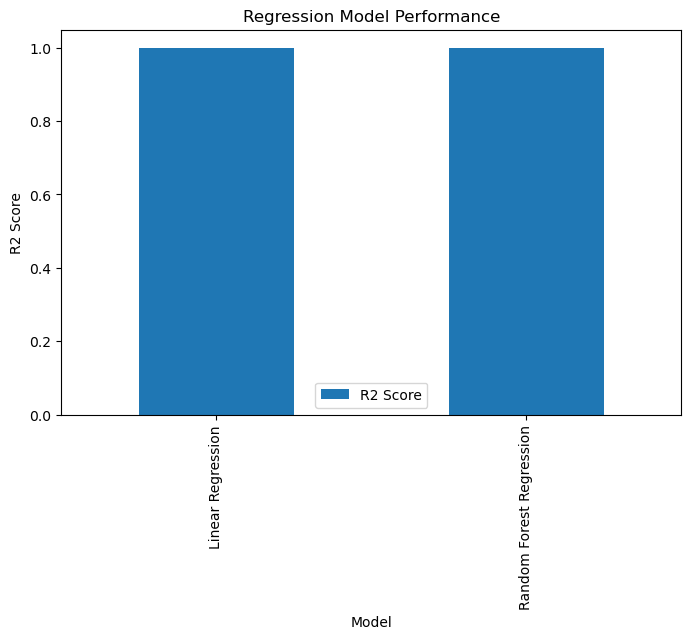

In [81]:
# Creating the regression model comparison chart
regression_results.plot(x="Model", y="R2 Score", kind="bar", figsize=(8, 5))

# Adding the chart title
plt.title("Regression Model Performance")

# Adding the y axis label
plt.ylabel("R2 Score")

# Displaying the chart
plt.show()

The performance of the regression models indicates that they have a very good predictive power with values of R² approximating to 1.0. Linear Regression fits perfectly, meaning there are strong relationships between the input features and target values. The R² score is also very good for Random Forest Regression. The models both give very precise forecasts with very little unexplained variance.

**Training the Decision Tree Classification Model**

A decision tree model was trained to make the classification of the customers based on the features associated with the churn. Class predictions and probability values were generated and classification performance was summarized for evaluation.

In [82]:
# Creating the decision tree classification pipeline
decision_tree_model = Pipeline(steps=[("processor", preprocessor), ("model", DecisionTreeClassifier(random_state=42))])

# Training the decision tree model
decision_tree_model.fit(X_train, y_train)

# Generating churn predictions
dt_prediction = decision_tree_model.predict(X_test)

# Generating churn probability values
dt_probability = decision_tree_model.predict_proba(X_test)[:, 1]

# Displaying classification results
print(classification_report(y_test, dt_prediction))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1035
           1       0.50      0.51      0.50       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.73      0.73      1409



**Evaluating Decision Tree Performance**

The accuracy, F1-scores and the ROC AUC were used to evaluate the performance of the decision tree. Calculated results were shown and the quality of classification of the model was evaluated.

In [83]:
# Calculating decision tree accuracy
dt_accuracy = accuracy_score(y_test, dt_prediction)

# Calculating decision tree F1 score
dt_f1 = f1_score(y_test, dt_prediction)

# Calculating decision tree ROC AUC
dt_auc = roc_auc_score(y_test, dt_probability)

# Displaying decision tree accuracy
print("Decision Tree Accuracy:", dt_accuracy)

# Displaying decision tree F1 score
print("Decision Tree F1 Score:", dt_f1)

# Displaying decision tree ROC AUC
print("Decision Tree ROC-AUC:", dt_auc)

Decision Tree Accuracy: 0.7338537970191625
Decision Tree F1 Score: 0.5046235138705416
Decision Tree ROC-AUC: 0.6626043039086518


**Visualizing the Decision Tree Confusion Matrix**

Confusion matrix was used for summarising classification results, comparing the actual churn and predicted churn. A heatmap was created to make the right and wrong prediction made by the decision tree model obvious.

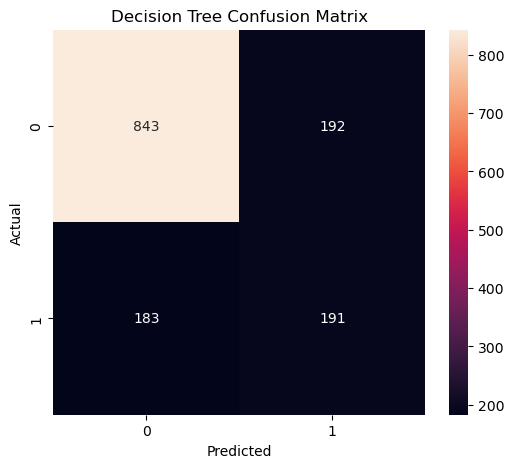

In [84]:
# Creating the confusion matrix figure
plt.figure(figsize=(6, 5))

# Displaying the confusion matrix
sns.heatmap(confusion_matrix(y_test, dt_prediction), annot=True, fmt="d")

# Adding the chart title
plt.title("Decision Tree Confusion Matrix")

# Adding the x axis label
plt.xlabel("Predicted")

# Adding the y axis label
plt.ylabel("Actual")

# Displaying the chart
plt.show()

The decision tree confusion matrix indicates 843 correct negative classifications and 191 correct positive classifications. Among false positive cases, there are 192 cases, that is some of the non-churn cases were wrongly predicted as churn. The false negative cases count is 183, which represents the number of "misidentified churn customers. Model performance reveals a balanced classification, leaving room for enhancing churn detection performance.

**Tuning the Decision Tree Model**

Various splitting criteria and depths of trees were tried to find the best performing decision tree model. Five fold validation was performed, using the F1 score as the selection criterion and limited processing was used to minimize memory consumption.

In [85]:
# Importing the grid search method
from sklearn.model_selection import GridSearchCV

# Creating the decision tree pipeline
dt_pipeline = Pipeline(steps=[("processor", preprocessor), ("model", DecisionTreeClassifier(random_state=42))])

# Defining decision tree parameter values
dt_parameters = {"model__max_depth": [3, 5, 7, 10], "model__criterion": ["gini", "entropy"]}

# Setting up the grid search
grid_dt = GridSearchCV(estimator=dt_pipeline, param_grid=dt_parameters, cv=5, scoring="f1", n_jobs=1, verbose=1)

# Training the tuned decision tree
grid_dt.fit(X_train, y_train)

# Showing the best parameter values
print("Best Parameters:")
print(grid_dt.best_params_)

# Saving the best decision tree model
best_dt = grid_dt.best_estimator_

# Confirming successful tuning
print("Decision Tree tuning completed successfully")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters:
{'model__criterion': 'entropy', 'model__max_depth': 3}
Decision Tree tuning completed successfully


**Evaluating the Tuned Decision Tree**

The accuracy of the classification performance of the tuned decision tree was tested on the test data. These metrics were computed and shown for comparison, such as accuracy, F1 score and ROC AUC values.

In [86]:
# Generating predictions from the tuned decision tree
best_dt_prediction = best_dt.predict(X_test)

# Generating probability values from the tuned decision tree
best_dt_probability = best_dt.predict_proba(X_test)[:, 1]

# Calculating tuned decision tree accuracy
best_dt_accuracy = accuracy_score(y_test, best_dt_prediction)

# Calculating tuned decision tree F1 score
best_dt_f1 = f1_score(y_test, best_dt_prediction)

# Calculating tuned decision tree ROC AUC
best_dt_auc = roc_auc_score(y_test, best_dt_probability)

# Displaying accuracy
print("Accuracy:", best_dt_accuracy)

# Displaying F1 score
print("F1 Score:", best_dt_f1)

# Displaying ROC AUC
print("ROC-AUC:", best_dt_auc)

Accuracy: 0.7508871540099361
F1 Score: 0.5584905660377358
ROC-AUC: 0.7870521067452013


**Training the KNN Classification Model**

The prepared set of features were used to train the KNN model in order to classify the customer based on churn. Classes and the values of probability were predicted and the classification result was shown and evaluated.

In [87]:
# Creating the KNN classification pipeline
knn_model = Pipeline(steps=[("processor", preprocessor), ("model", KNeighborsClassifier(n_neighbors=7))])

# Training the KNN model
knn_model.fit(X_train, y_train)

# Generating churn predictions
knn_prediction = knn_model.predict(X_test)

# Generating churn probability values
knn_probability = knn_model.predict_proba(X_test)[:, 1]

# Displaying classification results
print(classification_report(y_test, knn_prediction))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1035
           1       0.56      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



**Evaluating KNN Performance**

The accuracy, F1 score, and ROC AUC were used for the evaluation of the KNN model. The performance values were calculated and displayed to evaluate the classification performance.

In [88]:
# Calculating KNN accuracy
knn_accuracy = accuracy_score(y_test, knn_prediction)

# Calculating KNN F1 score
knn_f1 = f1_score(y_test, knn_prediction)

# Calculating KNN ROC AUC
knn_auc = roc_auc_score(y_test, knn_probability)

# Displaying KNN accuracy
print("KNN Accuracy:", knn_accuracy)

# Displaying KNN F1 score
print("KNN F1 Score:", knn_f1)

# Displaying KNN ROC AUC
print("KNN ROC-AUC:", knn_auc)

KNN Accuracy: 0.7672107877927609
KNN F1 Score: 0.5555555555555556
KNN ROC-AUC: 0.8018548657934848


**Tuning the KNN Model**

Various numbers of neighbors and weighting schemes were tried to find a better KNN configuration. The best settings were selected using fivefold validation with the F1 score and limiting the amount of processing usage.

In [89]:
# Creating the KNN pipeline
knn_pipeline = Pipeline(steps=[("processor", preprocessor), ("model", KNeighborsClassifier())])

# Defining KNN parameter values
knn_parameters = {"model__n_neighbors": [3, 5, 7, 9], "model__weights": ["uniform", "distance"]}

# Setting up the grid search
grid_knn = GridSearchCV(estimator=knn_pipeline, param_grid=knn_parameters, cv=5, scoring="f1", n_jobs=1, verbose=1)

# Training the tuned KNN model
grid_knn.fit(X_train, y_train)

# Showing the best KNN parameters
print("Best KNN Parameters:")
print(grid_knn.best_params_)

# Saving the best KNN model
best_knn = grid_knn.best_estimator_

# Confirming successful tuning
print("KNN tuning completed successfully")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best KNN Parameters:
{'model__n_neighbors': 9, 'model__weights': 'uniform'}
KNN tuning completed successfully


**Evaluating the Tuned KNN Model**

The classification performance of the tuned KNN model was tested by the test dataset. Model assessment was done by calculating and reporting accuracy, F1 score and ROC AUC values.

In [90]:
# Generating predictions from the tuned KNN model
best_knn_prediction = best_knn.predict(X_test)

# Generating probability values from the tuned KNN model
best_knn_probability = best_knn.predict_proba(X_test)[:, 1]

# Calculating tuned KNN accuracy
best_knn_accuracy = accuracy_score(y_test, best_knn_prediction)

# Calculating tuned KNN F1 score
best_knn_f1 = f1_score(y_test, best_knn_prediction)

# Calculating tuned KNN ROC AUC
best_knn_auc = roc_auc_score(y_test, best_knn_probability)

# Displaying accuracy
print("Accuracy:", best_knn_accuracy)

# Displaying F1 score
print("F1 Score:", best_knn_f1)

# Displaying ROC AUC
print("ROC-AUC:", best_knn_auc)

Accuracy: 0.7757274662881476
F1 Score: 0.5752688172043011
ROC-AUC: 0.810699062233589


**Comparing Classification Models**

The models derived for the classification were compared based on accuracy, F1 score and ROC AUC. A comparison table was drawn up to compare the performances of the original and tuned models.

In [91]:
# Creating the classification comparison table
classification_results = pd.DataFrame({"Model": ["Decision Tree", "Tuned Decision Tree", "KNN", "Tuned KNN"], "Accuracy": [dt_accuracy, best_dt_accuracy, knn_accuracy, best_knn_accuracy], "F1 Score": [dt_f1, best_dt_f1, knn_f1, best_knn_f1], "ROC-AUC": [dt_auc, best_dt_auc, knn_auc, best_knn_auc]})

# Displaying rounded classification results
display(classification_results.round(4))

,Model,Accuracy,F1 Score,ROC-AUC
0,Decision Tree,0.7339,0.5046,0.6626
1,Tuned Decision Tree,0.7509,0.5585,0.7871
2,KNN,0.7672,0.5556,0.8019
3,Tuned KNN,0.7757,0.5753,0.8107


**Comparing Classification Model Performance**

The accuracy value, F1 and ROC AUC values were used to compare the classification models. The results of the performance differences between the original and tuned models were represented using a bar chart.

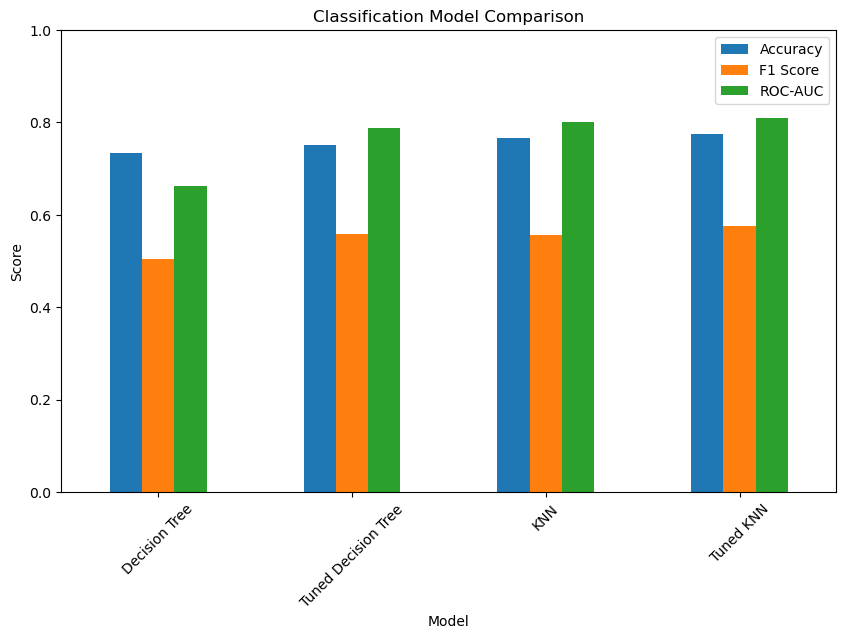

In [92]:
# Creating the classification performance chart
classification_results.plot(x="Model", y=["Accuracy", "F1 Score", "ROC-AUC"], kind="bar", figsize=(10, 6))

# Adding the chart title
plt.title("Classification Model Comparison")

# Adding the y axis label
plt.ylabel("Score")

# Setting the score range
plt.ylim(0, 1)

# Rotating model names
plt.xticks(rotation=45)

# Displaying the chart
plt.show()

The results of model comparisons indicate the benefit of tuning the models as compared to baseline models. The tuned KNN model has the best accuracy and ROC-AUC values, which suggest that it has a strong predictive capacity. Decision Tree tuned is more effective than the standard Decision Tree model. Model tuning is crucial for improving the performance of classification in terms of accuracy, F1 score and overall reliability.

**Comparing ROC Curves**

The ROC curves were made for the tuned decision tree and tuned KNN model based on their predicted probabilities. All curves were plotted together for comparing the classification performance for different threshold values.

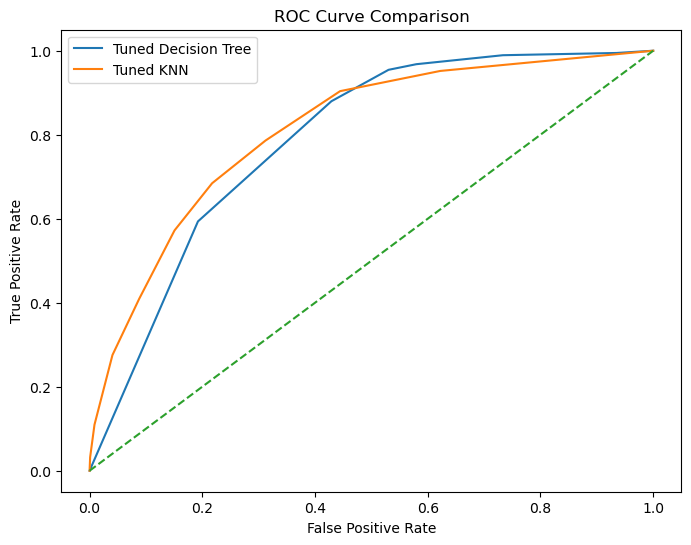

In [93]:
# Calculating ROC values for the tuned decision tree
dt_fpr, dt_tpr, _ = roc_curve(y_test, best_dt_probability)

# Calculating ROC values for the tuned KNN
knn_fpr, knn_tpr, _ = roc_curve(y_test, best_knn_probability)

# Creating the ROC curve figure
plt.figure(figsize=(8, 6))

# Plotting the tuned decision tree ROC curve
plt.plot(dt_fpr, dt_tpr, label="Tuned Decision Tree")

# Plotting the tuned KNN ROC curve
plt.plot(knn_fpr, knn_tpr, label="Tuned KNN")

# Adding the reference line
plt.plot([0, 1], [0, 1], linestyle="--")

# Adding the x axis label
plt.xlabel("False Positive Rate")

# Adding the y axis label
plt.ylabel("True Positive Rate")

# Adding the chart title
plt.title("ROC Curve Comparison")

# Showing the model labels
plt.legend()

# Displaying the chart
plt.show()

The comparison of ROC curve indicates that the classification performance of both tuned Decision Tree and KNN models is good. At a low rate of false positives, slightly better performance with high early true positive detection is achieved using tuned KNN. Tuned Decision Tree can get competitive results and improve discrimination capability on various thresholds. Both models have good performance for churn prediction with the ROC curves above the random line.

**Preparing Data for Customer Segmentation**

The customer data was segmented by preparing another data set excluding customer identifier and churn information. All other customer attributes were kept and clustered further.

In [94]:
# Creating a separate dataset for clustering
cluster_data = telco_data.copy()

# Removing customer identifier and churn columns
cluster_data = cluster_data.drop(columns=["customerID", "Churn"])

# Displaying the prepared clustering data
display(cluster_data.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


**Preparing Clustering Features**

Numerical and categorical features were separated based on their data types for customer segmentation. Selected feature names were presented to verify the variables that are ready for clustering.

In [95]:
# Selecting numerical clustering features
cluster_numeric = cluster_data.select_dtypes(include=["int64", "float64"]).columns

# Selecting categorical clustering features
cluster_categorical = cluster_data.select_dtypes(include=["object"]).columns

# Displaying numerical features
print("Numeric Features:", list(cluster_numeric))

# Displaying categorical features
print("Categorical Features:", list(cluster_categorical))

Numeric Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Preprocessing Clustering Data**

All numerical features were standardized and categorical features were coded as numerical for Customer Segmentation. Processed data was converted to a clustering matrix and the size of the matrix was displayed to verify the data.

In [96]:
# Creating the clustering preprocessing setup
cluster_processor = ColumnTransformer(transformers=[("numeric", StandardScaler(), cluster_numeric), ("categorical", OneHotEncoder(drop="first", sparse_output=False), cluster_categorical)])

# Transforming the clustering data
cluster_matrix = cluster_processor.fit_transform(cluster_data)

# Displaying the clustering matrix shape
print("Cluster Matrix Shape:", cluster_matrix.shape)

Cluster Matrix Shape: (7043, 30)


**Evaluating the Optimal Number of Clusters**

Various cluster numbers were tested to determine an appropriate number of clusters for customer segmentation. Cluster counts were then used to calculate silhouette scores which were then summarized to compare the quality of the groups.

In [97]:
# Importing the silhouette score measure
from sklearn.metrics import silhouette_score

# Creating an empty list for silhouette scores
silhouette_scores = []

# Defining the cluster range
cluster_range = range(2, 10)

# Testing different numbers of clusters
for k in cluster_range:
    # Showing the current cluster count
    print("Testing clusters:", k)

    # Creating the K Means model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Assigning cluster labels
    labels = kmeans.fit_predict(cluster_matrix)

    # Calculating the silhouette score
    score = silhouette_score(cluster_matrix, labels, sample_size=1000, random_state=42)

    # Storing the silhouette score
    silhouette_scores.append(score)

# Creating the silhouette results table
silhouette_results = pd.DataFrame({"Number of Clusters": list(cluster_range), "Silhouette Score": silhouette_scores})

# Displaying the silhouette results
display(silhouette_results)

Testing clusters: 2
Testing clusters: 3
Testing clusters: 4
Testing clusters: 5
Testing clusters: 6
Testing clusters: 7
Testing clusters: 8
Testing clusters: 9


,Number of Clusters,Silhouette Score
0,2,0.272065
1,3,0.263463
2,4,0.272220
3,5,0.262647
4,6,0.221169
5,7,0.199007
6,8,0.192008
7,9,0.175698


**Visualizing Silhouette Scores**

Different number of clusters were tried and plotted their silhouette scores to find an appropriate number of clusters. The line chart displayed the trend of clustering quality with varying numbers of clusters.

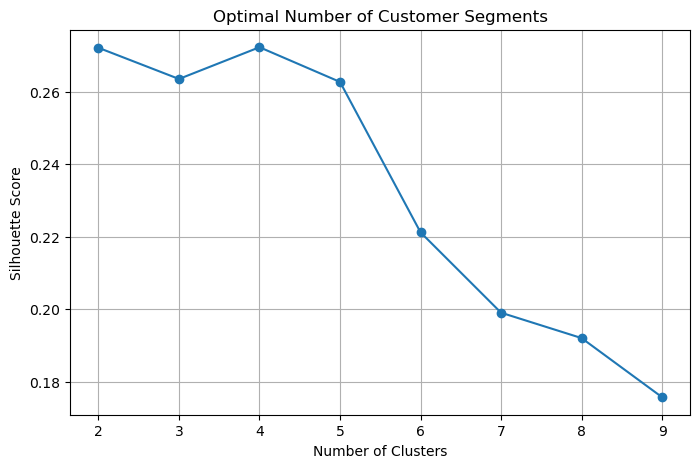

In [98]:
# Creating the silhouette score figure
plt.figure(figsize=(8, 5))

# Plotting silhouette scores
plt.plot(silhouette_results["Number of Clusters"], silhouette_results["Silhouette Score"], marker="o")

# Adding the x axis label
plt.xlabel("Number of Clusters")

# Adding the y axis label
plt.ylabel("Silhouette Score")

# Adding the chart title
plt.title("Optimal Number of Customer Segments")

# Adding grid lines
plt.grid()

# Displaying the chart
plt.show()

The silhouette score analysis has identified four clusters as the best customer segmentation option. The four clusters with the best silhouette scores have the most distinct separation and compactness between segments. Increasing the number of clusters beyond four results in a gradual decline in clustering quality. Four segments is the optimum number of segments to describe customer patterns.

**Selecting the Optimal Number of Clusters**

Based on the evaluation results, the cluster with the largest silhouette score was determined. The resulting number of clusters was presented as the most optimum number for cluster segmentation of the customers.

In [99]:
# Selecting the cluster count with the highest silhouette score
best_cluster = silhouette_results.loc[silhouette_results["Silhouette Score"].idxmax(), "Number of Clusters"]

# Displaying the optimal cluster count
print("Optimal Number of Clusters:", best_cluster)

Optimal Number of Clusters: 4


**Visualising the Optimal Cluster Score**

Silhouette scores were plotted as a function of number of clusters to emphasize the quality of the clustering as a function of the number of groups. The visualization was able to aid in choosing the cluster count that has the best silhouette score.

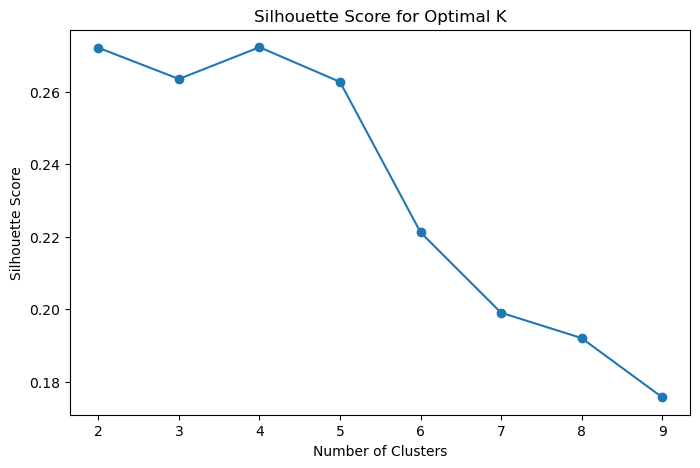

In [100]:
# Creating the silhouette score figure
plt.figure(figsize=(8, 5))

# Plotting silhouette scores across cluster counts
plt.plot(silhouette_results["Number of Clusters"], silhouette_results["Silhouette Score"], marker="o")

# Adding the chart title
plt.title("Silhouette Score for Optimal K")

# Adding the x axis label
plt.xlabel("Number of Clusters")

# Adding the y axis label
plt.ylabel("Silhouette Score")

# Displaying the chart
plt.show()

Four clusters appear to be the optimum number based on silhouette score analysis. It is observed that four clusters have the highest silhouette score, which indicates good separation and good intra-cluster compactness. More than four clusters causes the silhouette scores to drop and the quality of segmentation decreases. The grouping structure that's most appropriate for customer analysis is four-cluster segmentation.

**Creating the Final K Means Model**

The final customer segmentation model was generated based on the number of clusters selected. The customer records were clustered and the number of customers in each cluster shown.

In [101]:
# Creating the final K Means model
final_kmeans = KMeans(n_clusters=int(best_cluster), random_state=42, n_init=10)

# Assigning final cluster labels
cluster_labels = final_kmeans.fit_predict(cluster_matrix)

# Adding cluster labels to the customer data
telco_data["Cluster"] = cluster_labels

# Displaying customer counts by cluster
print(telco_data["Cluster"].value_counts())

Cluster
3    2674
1    1849
0    1526
2     994
Name: count, dtype: int64


**Reducing Clustering Data with PCA**

The clustering features were condensed to two principal components for simplicity of the customer segmentation results. A new table was set up for the two components and assigned cluster labels, for additional visualisation.

In [102]:
# Creating the PCA model
pca = PCA(n_components=2)

# Transforming the clustering data into two components
pca_components = pca.fit_transform(cluster_matrix)

# Creating the PCA results table
pca_df = pd.DataFrame({"PCA1": pca_components[:, 0], "PCA2": pca_components[:, 1], "Cluster": cluster_labels})

# Displaying the first five PCA records
display(pca_df.head())

,PCA1,PCA2,Cluster
0,-1.477684,-1.155061,3
1,-0.336523,0.037470,3
2,-1.126894,-1.169607,3
3,-0.258023,0.432799,3
4,-0.784891,-1.761428,3


**Visualizing Customer Segments**

The first two principal components from PCA results were used to visualize the customer segments. A scatter graph displayed the distribution and the distinctiveness of the clusters of customers.

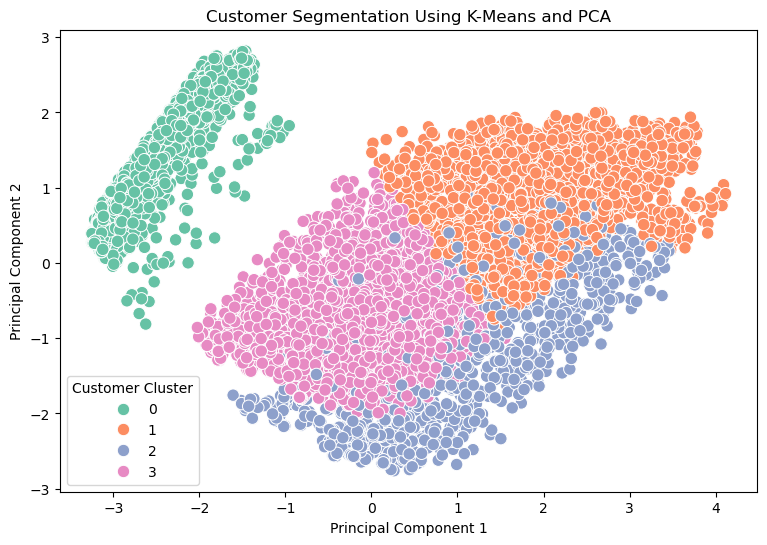

In [103]:
# Creating the customer cluster figure
plt.figure(figsize=(9, 6))

# Plotting customer clusters
sns.scatterplot(data=pca_df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=80)

# Adding the chart title
plt.title("Customer Segmentation Using K-Means and PCA")

# Adding the x axis label
plt.xlabel("Principal Component 1")

# Adding the y axis label
plt.ylabel("Principal Component 2")

# Adding the cluster legend
plt.legend(title="Customer Cluster")

# Displaying the chart
plt.show()

K Means Clustering with PCA Visualization Segments Customers into Four Segments by Clusters on the basis of the similarities of the features. Each group is clearly separated in the cluster groups, suggesting that there are significant differences between the customer characteristics. PCA components are good for representing variation in customer data and visualization of the segments. There are four customer segments that can be used as a framework to analyse customer behaviour and patterns.

**Profiling Customer Clusters**

The average values for senior customer status and tenure, monthly and total charges were used to summarize customer clusters. The profile had been rounded off to 2 decimal places and shown for comparison of the key features of each of the customer groups.

In [104]:
# Creating the customer cluster profile
cluster_profile = telco_data.groupby("Cluster").agg({"SeniorCitizen": "mean", "tenure": "mean", "MonthlyCharges": "mean", "TotalCharges": "mean"})

# Rounding cluster profile values
cluster_profile = cluster_profile.round(2)

# Displaying the cluster profile
display(cluster_profile)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Cluster,,,,
0,0.03,30.55,21.08,662.69
1,0.05,59.30,89.64,5308.54
2,1.00,29.37,80.45,2476.09
3,0.00,15.91,66.65,1035.39


**Analyzing Cluster Size Distribution**

The count of customers in each of the clusters was determined to compare the magnitude of the customer segments. Sizes of clusters were represented and summarized in a bar chart for convenient comparison.

Cluster
3    2674
1    1849
0    1526
2     994
Name: count, dtype: int64

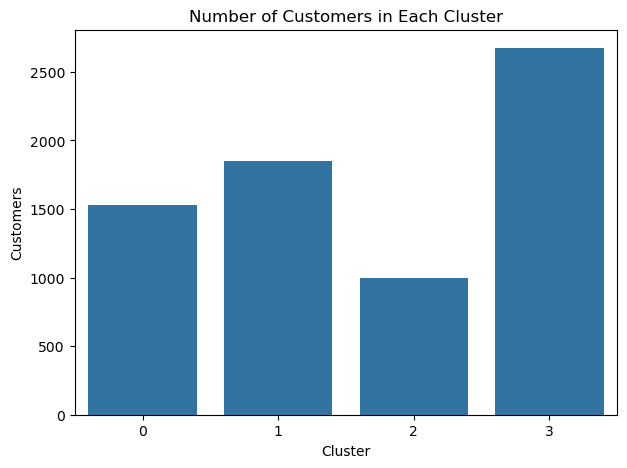

In [105]:
# Calculating the number of customers in each cluster
cluster_size = telco_data["Cluster"].value_counts()

# Displaying cluster sizes
display(cluster_size)

# Creating the cluster size chart
plt.figure(figsize=(7, 5))

# Plotting customer counts by cluster
sns.barplot(x=cluster_size.index, y=cluster_size.values)

# Adding the chart title
plt.title("Number of Customers in Each Cluster")

# Adding the x axis label
plt.xlabel("Cluster")

# Adding the y axis label
plt.ylabel("Customers")

# Displaying the chart
plt.show()

The distribution of customers by cluster reveals different numbers of customers in four customer segments. The largest customer segment is Cluster 3, which has the most customers. Customer group 2 has the least number of customers which means it is a more specific customer group. Imbalanced clusters reveal discrepancies in the customer characteristics and segment coverages.

**Analyzing Churn by Customer Segment**

Customer churn percentages were determined to compare customer churn levels among identified customer segments. Results were rounded to two decimal places and presented for easier comparisons.

In [106]:
# Calculating churn percentages by cluster
cluster_churn = telco_data.groupby("Cluster")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)

# Rounding churn percentages
cluster_churn = cluster_churn.round(2)

# Displaying churn percentages by cluster
display(cluster_churn)

Cluster
0     7.40
1    12.66
2    46.58
3    39.60
Name: Churn, dtype: float64

**Visualizing Churn Rate by Customer Segment**

The proportion of customers churned within each cluster was plotted for each customer segment to make it easier to compare the churn rate of each cluster. The bar graph clearly highlighted the difference in churn rates among various customer groups.

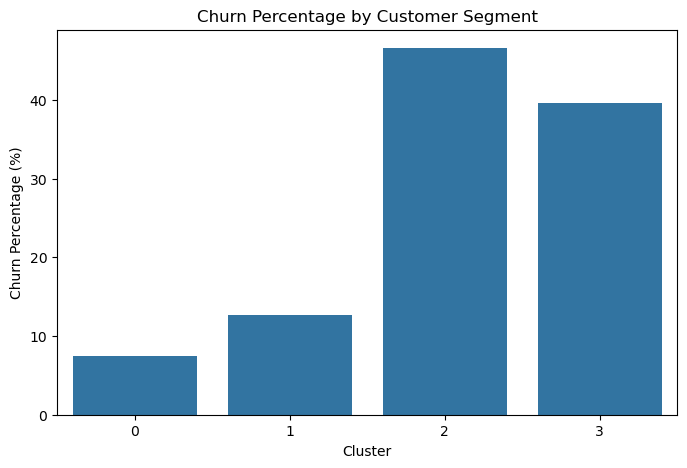

In [107]:
# Creating the churn rate figure
plt.figure(figsize=(8, 5))

# Plotting churn percentages by cluster
sns.barplot(x=cluster_churn.index, y=cluster_churn.values)

# Adding the chart title
plt.title("Churn Percentage by Customer Segment")

# Adding the x axis label
plt.xlabel("Cluster")

# Adding the y axis label
plt.ylabel("Churn Percentage (%)")

# Displaying the chart
plt.show()

The churn percentage varies greatly between four customer segment clusters. The churn percentage is the worst in Cluster 2, suggesting that it may have a harder time retaining customers. The churn rate for Cluster 0 is the lowest, showing that this group is more stable. It is important to have strategies in place to improve customer retention and minimise customer loss for high churn segments.

**Identifying the Highest Risk Customer Segment**

The cluster results identified the customer segment that had the highest churn percentage. For further analysis the highest risk cluster and its churn percentage were shown.

In [108]:
# Identifying the cluster with the highest churn rate
highest_risk_cluster = cluster_churn.idxmax()

# Identifying the highest churn percentage
highest_risk_value = cluster_churn.max()

# Displaying the highest risk cluster
print("Highest Risk Customer Cluster:", highest_risk_cluster)

# Displaying the highest churn percentage
print("Churn Percentage:", highest_risk_value, "%")

Highest Risk Customer Cluster: 2
Churn Percentage: 46.58 %


**Generating Automated Cluster Insights**

The main customer segmentation findings were summarized by the identified number of clusters and by the highest churn segment. The summary indicated the highest risk group, and recommended retention actions based on the risk observed in the churn rate.

In [109]:
# Creating automated customer segmentation insights
print(f"""
Customer Segmentation Insights

Total Customer Segments Created: 4

Highest Churn Risk Segment:
Cluster {highest_risk_cluster}

Churn Rate:
{highest_risk_value}%

Business Action:
Focus retention campaigns,
discount programs, and support services
on this customer segment.
""")


Customer Segmentation Insights

Total Customer Segments Created: 4

Highest Churn Risk Segment:
Cluster 2

Churn Rate:
46.58%

Business Action:
Focus retention campaigns,
discount programs, and support services
on this customer segment.



**Preparing Transactions for Association Rule Mining**

Customer service and churn attributes selected were converted to transaction items for association analysis. Each customer record was represented as a group of attribute and value pairs, and the total number of transactions was displayed.

In [110]:
# Selecting attributes for association analysis
association_columns = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity", "PaperlessBilling", "Churn"]

# Creating an empty transaction list
transactions = []

# Preparing transactions from customer records
for _, row in telco_data[association_columns].iterrows():
    # Creating an empty item list
    items = []

    # Adding attribute and value pairs
    for col in association_columns:
        items.append(col + "=" + str(row[col]))

    # Saving each customer transaction
    transactions.append(items)

# Displaying the total transaction count
print("Total Transactions:", len(transactions))

Total Transactions: 7043


**Converting Transactions into Binary Format**

The customer transactions were converted to a binary format, each of the attribute value was encoded as a separate feature. The data from the transactions was duly restructured and the initial records were shown to review.

In [111]:
# Creating the transaction encoder
transaction_encoder = TransactionEncoder()

# Transforming transactions into binary values
transaction_array = transaction_encoder.fit(transactions).transform(transactions)

# Creating the binary transaction table
transaction_df = pd.DataFrame(transaction_array, columns=transaction_encoder.columns_)

# Displaying the first five transactions
display(transaction_df.head())

,Churn=No,Churn=Yes,Contract=Month-to-month,Contract=One year,Contract=Two year,InternetService=DSL,InternetService=Fiber optic,InternetService=No,OnlineSecurity=No,OnlineSecurity=No internet service,OnlineSecurity=Yes,PaperlessBilling=No,PaperlessBilling=Yes,PaymentMethod=Bank transfer (automatic),PaymentMethod=Credit card (automatic),PaymentMethod=Electronic check,PaymentMethod=Mailed check,TechSupport=No,TechSupport=No internet service,TechSupport=Yes
0,True,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,True,False,False
1,True,False,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False
2,False,True,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,True,False,False
3,True,False,False,True,False,True,False,False,False,False,True,True,False,True,False,False,False,False,False,True
4,False,True,True,False,False,False,True,False,True,False,False,False,True,False,False,True,False,True,False,False


**Finding Frequent Itemsets with Apriori**

A minimum support level of 5 percent was used to discover frequent combinations of customer attributes. The itemsets were sorted by the support value and the 10 most frequent itemsets were shown.

In [112]:
# Finding frequent customer itemsets
frequent_itemsets = apriori(transaction_df, min_support=0.05, use_colnames=True)

# Sorting itemsets by support
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

# Displaying the ten most frequent itemsets
display(frequent_itemsets.head(10))

,support,itemsets
0,0.734630,(Churn=No)
12,0.592219,(PaperlessBilling=Yes)
2,0.550192,(Contract=Month-to-month)
8,0.496663,(OnlineSecurity=No)
17,0.493114,(TechSupport=No)
6,0.439585,(InternetService=Fiber optic)
11,0.407781,(PaperlessBilling=No)
30,0.393440,"(Churn=No, PaperlessBilling=Yes)"
58,0.380520,"(Contract=Month-to-month, TechSupport=No)"
49,0.373562,"(Contract=Month-to-month, OnlineSecurity=No)"


**Generating Association Rules**

The frequent customer itemsets were used to form association rules with a 50 per cent confidence level. Rules that had lift over one were kept, ranked by lift and the strongest rules were selected.

In [113]:
# Generating association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Keeping rules with positive association
rules = rules[rules["lift"] > 1]

# Sorting rules by lift
rules = rules.sort_values(by="lift", ascending=False)

# Displaying the ten strongest rules
display(rules.head(10))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1900,"(TechSupport=No internet service, Contract=Two...","(Churn=No, PaperlessBilling=No, InternetServic...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288
1887,"(OnlineSecurity=No internet service, Contract=...","(Churn=No, PaperlessBilling=No, InternetServic...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288
1889,"(Contract=Two year, InternetService=No)","(Churn=No, OnlineSecurity=No internet service,...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288
1902,"(Contract=Two year, InternetService=No)","(TechSupport=No internet service, Churn=No, Pa...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288
1924,"(OnlineSecurity=No internet service, Contract=...","(TechSupport=No internet service, Churn=No, Pa...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288
1928,"(TechSupport=No internet service, Contract=Two...","(Churn=No, OnlineSecurity=No internet service,...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288
1929,"(OnlineSecurity=No internet service, Contract=...","(TechSupport=No internet service, Churn=No, Pa...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288
1918,"(TechSupport=No internet service, OnlineSecuri...","(Churn=No, PaperlessBilling=No, InternetServic...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288
1943,"(OnlineSecurity=No internet service, Contract=...","(TechSupport=No internet service, Churn=No, Pa...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288
1921,"(TechSupport=No internet service, Contract=Two...","(Churn=No, OnlineSecurity=No internet service,...",0.090586,0.143263,0.065739,0.725705,5.065553,1.0,0.052761,3.123419,0.882534,0.391047,0.679838,0.592288


**Visualizing Association Rules**

Relationships between support and confidence values were plotted to compare the associated strength of the rules. Point sizes signified lift values to convey Rules that had a higher association.

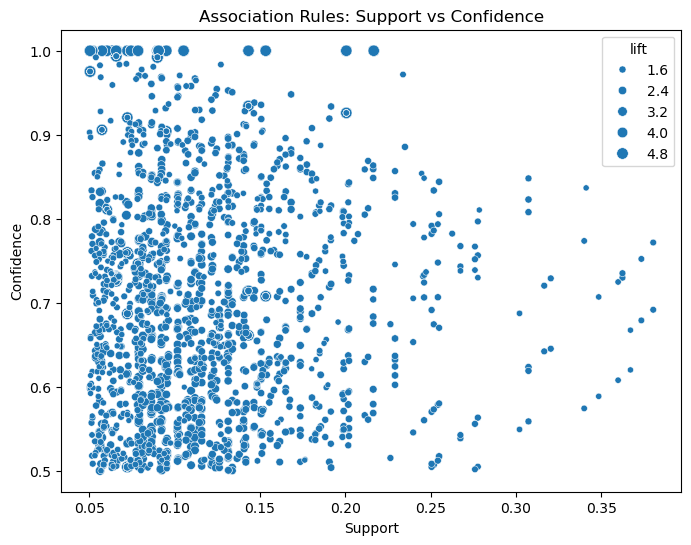

In [114]:
# Creating the support and confidence figure
plt.figure(figsize=(8, 6))

# Plotting support against confidence
sns.scatterplot(data=rules, x="support", y="confidence", size="lift")

# Adding the chart title
plt.title("Association Rules: Support vs Confidence")

# Adding the x axis label
plt.xlabel("Support")

# Adding the y axis label
plt.ylabel("Confidence")

# Displaying the chart
plt.show()

Association rules have a wide range of supports, with a large proportion of rules with lower supports. The confidence values are high, and there is a good level of confidence in the association rules generated. There are a number of rules with higher lift values, indicating more robust relationships between some combinations of items. Rules that are moderately supported and highly confident offer useful information on determining meaningful associations.

**Identifying Churn Related Association Rules**

Association rules that are associated with customer churn were removed from the rules generated. The rules that showed the greatest churn were displayed to see what attributes of the customers were associated with churn.

In [115]:
# Filtering rules related to customer churn
churn_rules = rules[rules["consequents"].astype(str).str.contains("Churn=Yes")]

# Displaying the top churn related rules
display(churn_rules.head(10))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1522,"(PaymentMethod=Electronic check, PaperlessBill...","(Contract=Month-to-month, Churn=Yes, InternetS...",0.155474,0.164987,0.078944,0.507763,3.077600,1.0,0.053293,1.696363,0.799349,0.326867,0.410504,0.493124
1492,"(Contract=Month-to-month, TechSupport=No, Onli...","(InternetService=Fiber optic, Churn=Yes)",0.141701,0.184154,0.078944,0.557114,3.025255,1.0,0.052849,1.842113,0.779972,0.319724,0.457145,0.492898
1517,"(PaymentMethod=Electronic check, Contract=Mont...","(Churn=Yes, OnlineSecurity=No, TechSupport=No)",0.150504,0.177481,0.078944,0.524528,2.955402,1.0,0.052232,1.729901,0.778858,0.316990,0.421932,0.484664
1500,"(Contract=Month-to-month, OnlineSecurity=No, P...","(Churn=Yes, TechSupport=No)",0.131478,0.205310,0.078944,0.600432,2.924511,1.0,0.051950,1.988872,0.757681,0.306167,0.497202,0.492470
1496,"(Contract=Month-to-month, TechSupport=No, Paym...","(Churn=Yes, OnlineSecurity=No)",0.131478,0.207440,0.078944,0.600432,2.894485,1.0,0.051670,1.983542,0.753597,0.303659,0.495851,0.490497
1520,"(PaymentMethod=Electronic check, InternetServi...","(Contract=Month-to-month, Churn=Yes, Paperless...",0.153912,0.177339,0.078944,0.512915,2.892283,1.0,0.051649,1.688948,0.773267,0.312887,0.407915,0.479036
1340,"(PaymentMethod=Electronic check, Contract=Mont...","(InternetService=Fiber optic, Churn=Yes)",0.165128,0.184154,0.086611,0.524506,2.848183,1.0,0.056202,1.715784,0.777244,0.329730,0.417176,0.497411
1437,"(PaymentMethod=Electronic check, PaperlessBill...","(InternetService=Fiber optic, Churn=Yes)",0.155474,0.184154,0.081357,0.523288,2.841569,1.0,0.052726,1.711400,0.767391,0.315008,0.415683,0.482538
1370,"(PaymentMethod=Electronic check, Contract=Mont...","(InternetService=Fiber optic, Churn=Yes)",0.164987,0.184154,0.086327,0.523236,2.841287,1.0,0.055944,1.711214,0.776091,0.328471,0.415620,0.496005
1490,"(Contract=Month-to-month, TechSupport=No, Onli...","(Churn=Yes, PaperlessBilling=Yes)",0.140423,0.198779,0.078944,0.562184,2.828187,1.0,0.051030,1.830041,0.752017,0.303328,0.453564,0.479663


**Summarizing Final Classification Performance**

The final classification results were arranged to show the comparison of the original and tuned models, using three performance measures. Values of accuracy, F1 score and ROC AUC were rounded and presented for the last model assessment.

In [116]:
# Creating the final classification summary
final_classification_summary = pd.DataFrame({"Model": ["Decision Tree", "Tuned Decision Tree", "KNN", "Tuned KNN"], "Accuracy": [dt_accuracy, best_dt_accuracy, knn_accuracy, best_knn_accuracy], "F1 Score": [dt_f1, best_dt_f1, knn_f1, best_knn_f1], "ROC-AUC": [dt_auc, best_dt_auc, knn_auc, best_knn_auc]})

# Displaying the rounded final results
display(final_classification_summary.round(3))

,Model,Accuracy,F1 Score,ROC-AUC
0,Decision Tree,0.734,0.505,0.663
1,Tuned Decision Tree,0.751,0.558,0.787
2,KNN,0.767,0.556,0.802
3,Tuned KNN,0.776,0.575,0.811


**Analyzing Feature Importance**

The tuned decision tree model was used for analyzing the importance of the input features. The features were ranked according to their importance value and the top 15 features were shown.

In [117]:
# Selecting the trained decision tree
best_tree = best_dt.named_steps["model"]

# Getting the processed feature names
feature_names = best_dt.named_steps["processor"].get_feature_names_out()

# Creating the feature importance table
feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": best_tree.feature_importances_})

# Sorting features by importance
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Displaying the fifteen most important features
display(feature_importance.head(15))

,Feature,Importance
25,categorical__Contract_Two year,0.463825
24,categorical__Contract_One year,0.294320
10,categorical__InternetService_Fiber optic,0.163596
23,categorical__StreamingMovies_Yes,0.041833
2,numeric__MonthlyCharges,0.023670
3,numeric__TotalCharges,0.012756
5,categorical__Partner_Yes,0.000000
6,categorical__Dependents_Yes,0.000000
8,categorical__MultipleLines_No phone service,0.000000
7,categorical__PhoneService_Yes,0.000000


**Visualizing Top Predictive Features**

Based on the feature importance results, ten most important features were selected for churn prediction. A horizontal bar graph was used to visually show the effect of the top features on the model predictions.

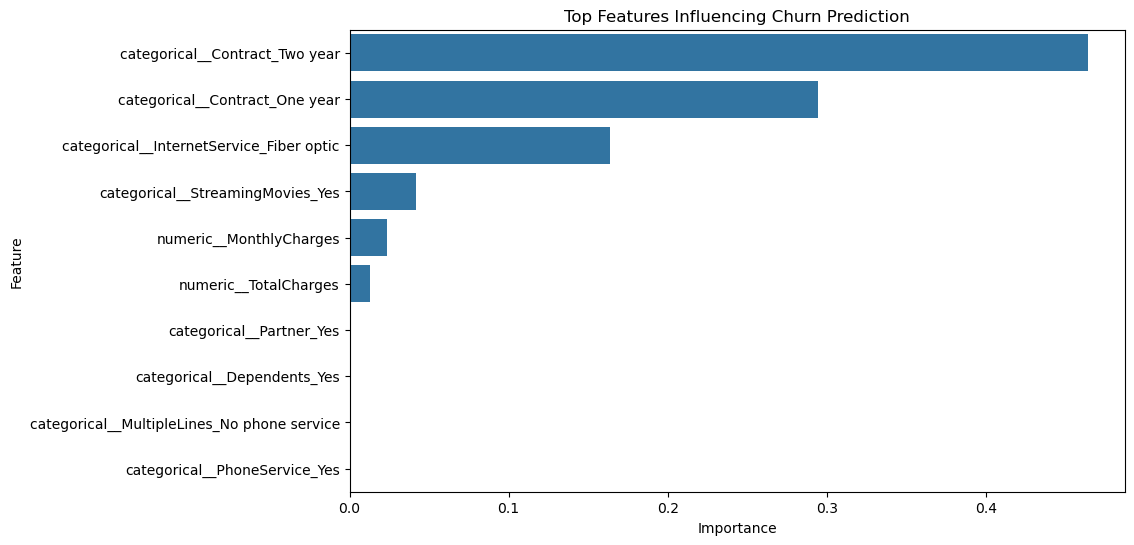

In [118]:
# Creating the feature importance figure
plt.figure(figsize=(10, 6))

# Plotting the top predictive features
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")

# Adding the chart title
plt.title("Top Features Influencing Churn Prediction")

# Displaying the chart
plt.show()

The contract duration shows the biggest impact on churn prediction, and is dominated by two-year and one-year contracts. Other examples of technology that have a significant impact on customer churn include fiber optic internet service and streaming movie subscriptions. The monthly charges and total charges have moderate influence, suggesting that billing factors matter in the churn prediction. The contribution of these features is small: Partner, dependent service, phone service, multiple lines.

**Creating Customer Retention Recommendations**

The results of the analysis were organised in the form of recommendations for customer retention, by priority. Retention campaigns, benefits for customers, service changes, offers for specific groups, and the continuous monitoring of models were all areas targeted in the recommendations.

In [119]:
# Creating the recommendation table
recommendations = pd.DataFrame({"Priority": ["High", "High", "Medium", "Medium", "Continuous"], "Recommendation": ["Create retention campaigns for month-to-month customers", "Provide discounts and loyalty benefits for high-risk customers", "Improve technical support and security service adoption", "Target high churn clusters with personalized offers", "Continue monitoring model fairness and performance"]})

# Displaying the recommendations
display(recommendations)

,Priority,Recommendation
0,High,Create retention campaigns for month-to-month ...
1,High,Provide discounts and loyalty benefits for hig...
2,Medium,Improve technical support and security service...
3,Medium,Target high churn clusters with personalized o...
4,Continuous,Continue monitoring model fairness and perform...
